In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

In [2]:
PALETTE      = ['#028090', '#F96167', '#F9E795', '#2F3C7E', '#97BC62', '#B85042']
PASS_PALETTE = {'Pass': '#028090', 'Fail': '#F96167'}
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})


In [3]:
df =pd.read_csv("StudentPerformanceFactors.csv")

In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
cols_to_drop = ['Internet_Access','Family_Income','Teacher_Quality','School_Type','Parental_Education_Level','Distance_from_Home'] 

df= df.drop(columns=cols_to_drop)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Tutoring_Sessions           6607 non-null   int64 
 9   Peer_Influence              6607 non-null   object
 10  Physical_Activity           6607 non-null   int64 
 11  Learning_Disabilities       6607 non-null   object
 12  Gender                      6607 non-null   object
 13  Exam_Score                  6607 non-null   int6

In [7]:
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


In [8]:
zeros_count = (df == 0).sum()
print(zeros_count)

Hours_Studied                    0
Attendance                       0
Parental_Involvement             0
Access_to_Resources              0
Extracurricular_Activities       0
Sleep_Hours                      0
Previous_Scores                  0
Motivation_Level                 0
Tutoring_Sessions             1513
Peer_Influence                   0
Physical_Activity               46
Learning_Disabilities            0
Gender                           0
Exam_Score                       0
dtype: int64


In [9]:
# Count missing values per column
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Tutoring_Sessions             0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Gender                        0
Exam_Score                    0
dtype: int64


In [10]:
for threshold in [50, 55, 60, 65, 70]:
    pass_rate = (df['Exam_Score'] >= threshold).mean()
    print(f'Threshold {threshold}: Pass rate = {pass_rate:.1%}')

Threshold 50: Pass rate = 100.0%
Threshold 55: Pass rate = 100.0%
Threshold 60: Pass rate = 99.0%
Threshold 65: Pass rate = 78.0%
Threshold 70: Pass rate = 24.6%


In [11]:
#feature Enginering
# Pass_Fail binary target
df['Pass_Fail'] = (df['Exam_Score'] >= 65).astype(int)
df['Pass_Fail_Label'] = df['Pass_Fail'].map({1: 'Pass', 0: 'Fail'})

counts = df['Pass_Fail_Label'].value_counts()
print('Pass/Fail distribution:')
print(counts.to_string())
print(f'\nPass rate: {counts["Pass"] / len(df):.1%}')

Pass/Fail distribution:
Pass_Fail_Label
Pass    5155
Fail    1452

Pass rate: 78.0%


In [12]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Exam_Score,Pass_Fail,Pass_Fail_Label
0,23,84,Low,High,No,7,73,Low,0,Positive,3,No,Male,67,1,Pass
1,19,64,Low,Medium,No,8,59,Low,2,Negative,4,No,Female,61,0,Fail
2,24,98,Medium,Medium,Yes,7,91,Medium,2,Neutral,4,No,Male,74,1,Pass
3,29,89,Low,Medium,Yes,8,98,Medium,1,Negative,4,No,Male,71,1,Pass
4,19,92,Medium,Medium,Yes,6,65,Medium,3,Neutral,4,No,Female,70,1,Pass


In [13]:
# Stress_Proxy composite feature
# Low sleep + low motivation + low study hours -> HIGH stress score (0-1)
motivation_map  = {'Low': 0, 'Medium': 1, 'High': 2}
motivation_num  = df['Motivation_Level'].map(motivation_map)

sleep_norm      = df['Sleep_Hours']   / df['Sleep_Hours'].max()
motivation_norm = motivation_num      / 2
hours_norm      = df['Hours_Studied'] / df['Hours_Studied'].max()

df['Stress_Proxy'] = ((1 - sleep_norm) + (1 - motivation_norm) + (1 - hours_norm)) / 3
df['Stress_Proxy'] = df['Stress_Proxy'].round(4)

print('Stress_Proxy stats:')
print(df['Stress_Proxy'].describe().round(4).to_string())
print('\nFeatures created: Pass_Fail, Stress_Proxy')

Stress_Proxy stats:
count    6607.0000
mean        0.4633
std         0.1336
min         0.0712
25%         0.3727
50%         0.4621
75%         0.5636
max         0.8364

Features created: Pass_Fail, Stress_Proxy


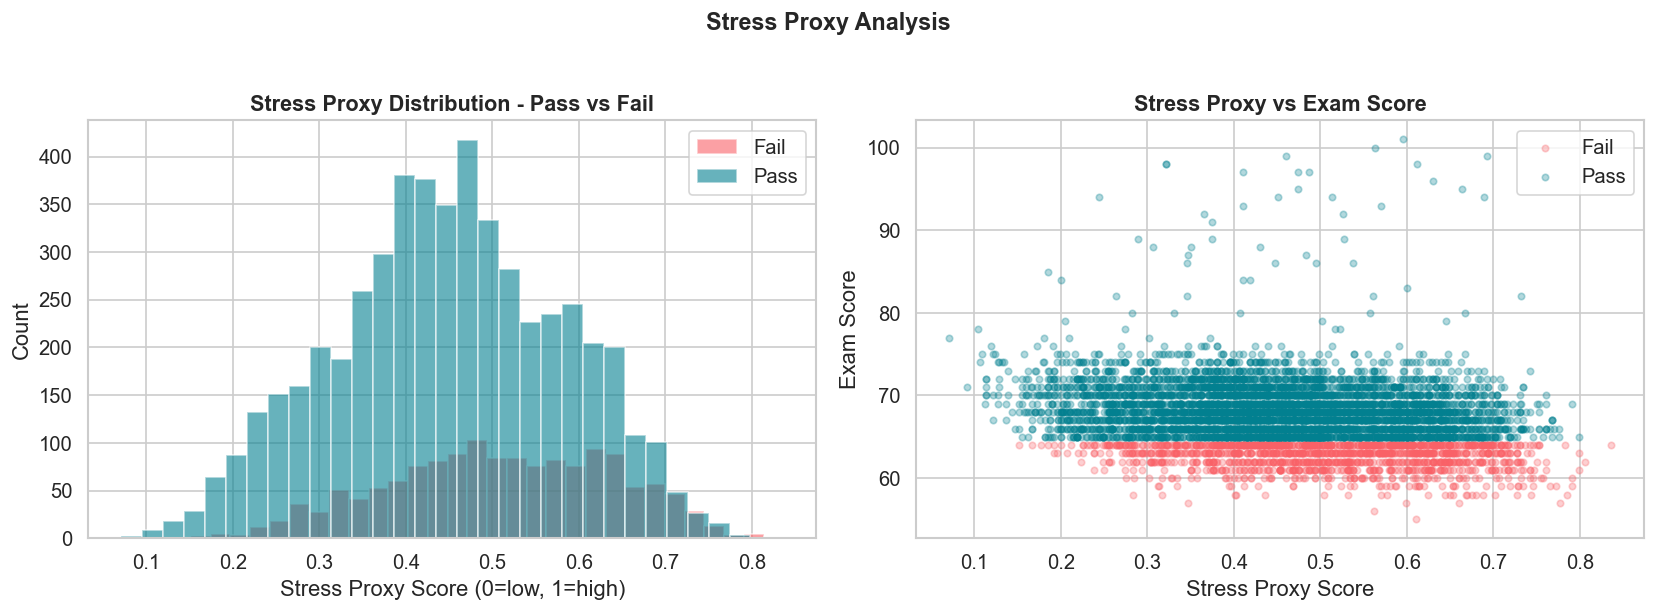

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, grp in df.groupby('Pass_Fail_Label'):
    axes[0].hist(grp['Stress_Proxy'], bins=30, alpha=0.6,
                 label=label, color=PASS_PALETTE[label], edgecolor='white')
axes[0].set_title('Stress Proxy Distribution - Pass vs Fail')
axes[0].set_xlabel('Stress Proxy Score (0=low, 1=high)')
axes[0].set_ylabel('Count')
axes[0].legend()

for label, grp in df.groupby('Pass_Fail_Label'):
    axes[1].scatter(grp['Stress_Proxy'], grp['Exam_Score'],
                    label=label, alpha=0.3, s=15, color=PASS_PALETTE[label])
axes[1].set_title('Stress Proxy vs Exam Score')
axes[1].set_xlabel('Stress Proxy Score')
axes[1].set_ylabel('Exam Score')
axes[1].legend()

plt.suptitle('Stress Proxy Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_08_stress_proxy.png', bbox_inches='tight')
plt.show()

In [15]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Pass_Fail', 'Stress_Proxy']]

report = []
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df[col] < lower) | (df[col] > upper)).sum()
    report.append({'column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                   'lower_fence': round(lower,2), 'upper_fence': round(upper,2),
                   'n_outliers': n_out, 'pct': round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(report).set_index('column')
print('IQR Outlier Report:')
display(outlier_df[outlier_df['n_outliers'] > 0])

IQR Outlier Report:


,Q1,Q3,lower_fence,upper_fence,n_outliers,pct
column,,,,,,
Hours_Studied,16.0,24.0,4.0,36.0,43,0.65
Tutoring_Sessions,1.0,2.0,-0.5,3.5,430,6.51
Exam_Score,65.0,69.0,59.0,75.0,104,1.57


In [16]:
# Z-score check on Exam_Score
z_scores = np.abs(stats.zscore(df['Exam_Score']))
extreme  = (z_scores > 3).sum()

print(f'Exam_Score range  : {df["Exam_Score"].min()} - {df["Exam_Score"].max()}')
print(f'Std deviation     : {df["Exam_Score"].std():.2f}')
print(f'Records |Z| > 3   : {extreme}')
print('\nDecision: narrow range (std approx 3.9), no outlier removal.')
print('Prioritize classification (Pass/Fail) over regression.')

Exam_Score range  : 55 - 101
Std deviation     : 3.89
Records |Z| > 3   : 52

Decision: narrow range (std approx 3.9), no outlier removal.
Prioritize classification (Pass/Fail) over regression.


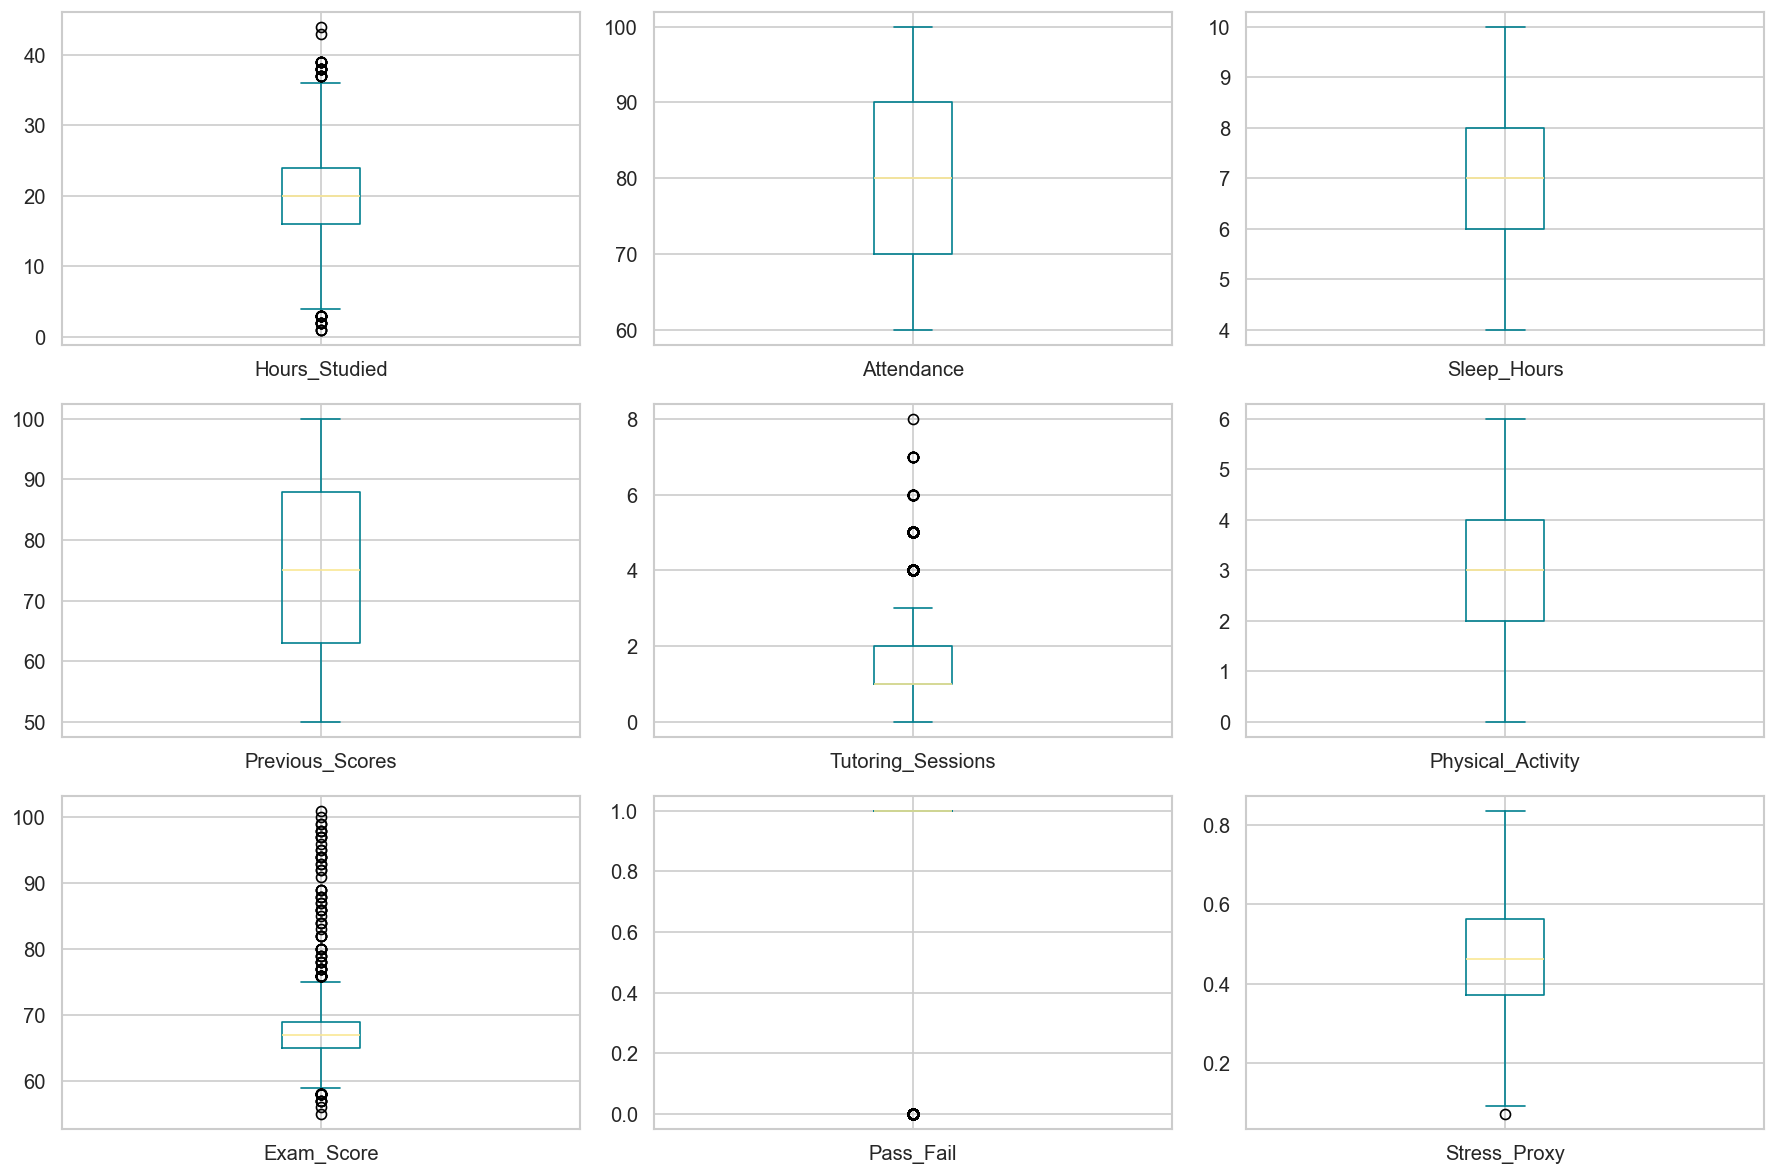

In [17]:
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

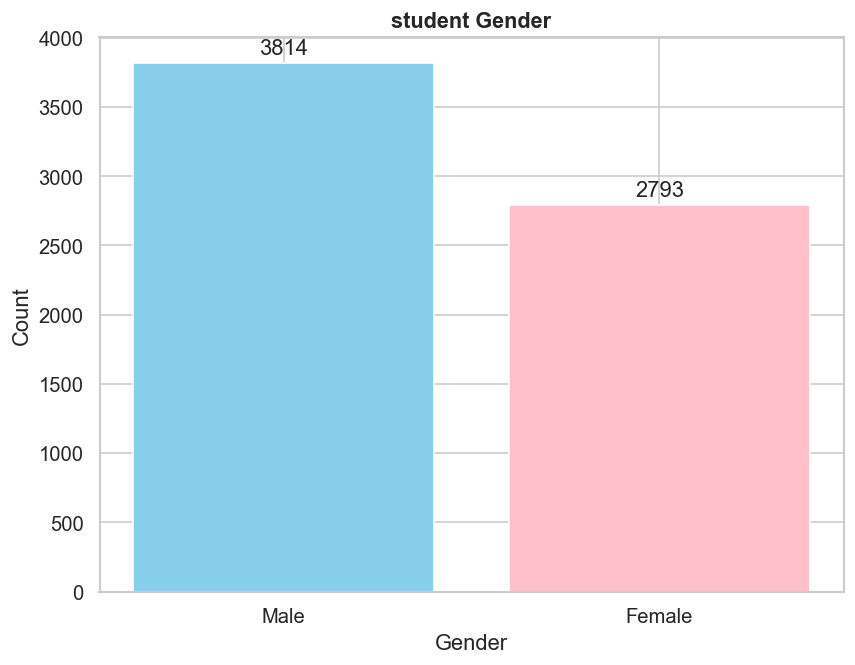

In [18]:
#student counts by gender using bar
counts = df["Gender"].value_counts()
 
plt.figure(figsize=(8,6))
bars=plt.bar(counts.index, counts.values, color=['skyblue', 'pink'])
plt.bar_label(bars, padding=3)
plt.title("student Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

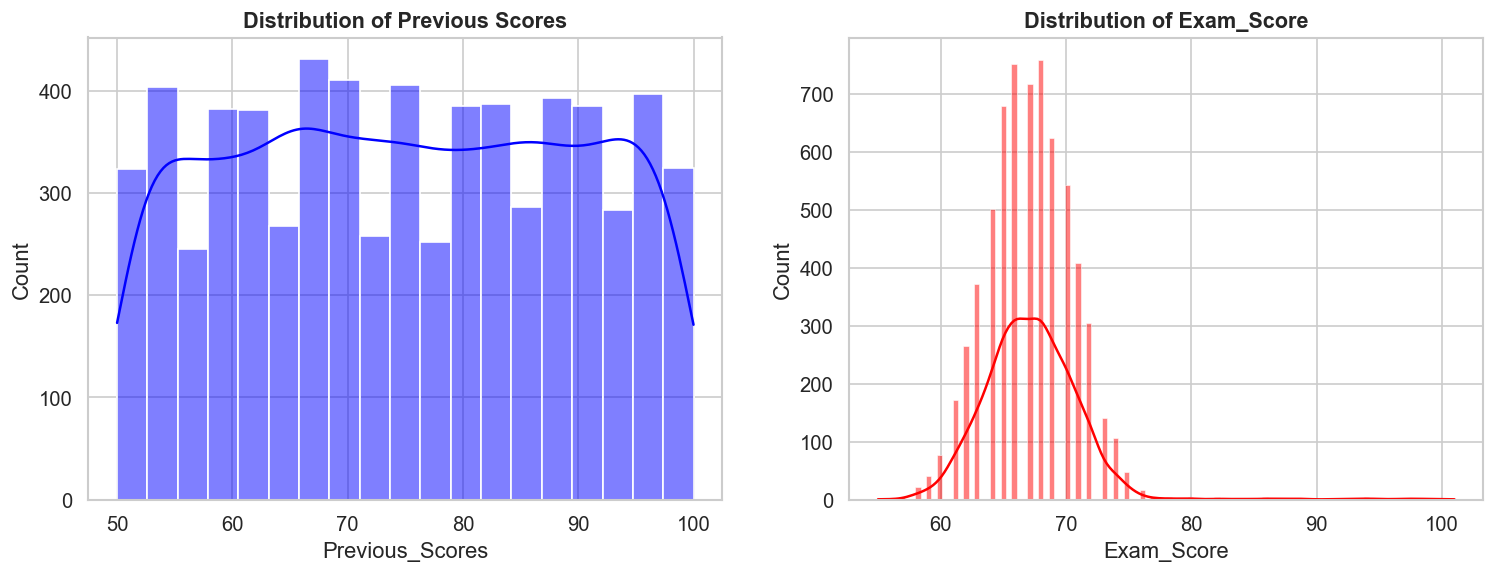

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Exam Score Distribution
sns.histplot(df['Previous_Scores'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Previous Scores')

#Age Distribution
sns.histplot(df['Exam_Score'], kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Exam_Score')

plt.show()

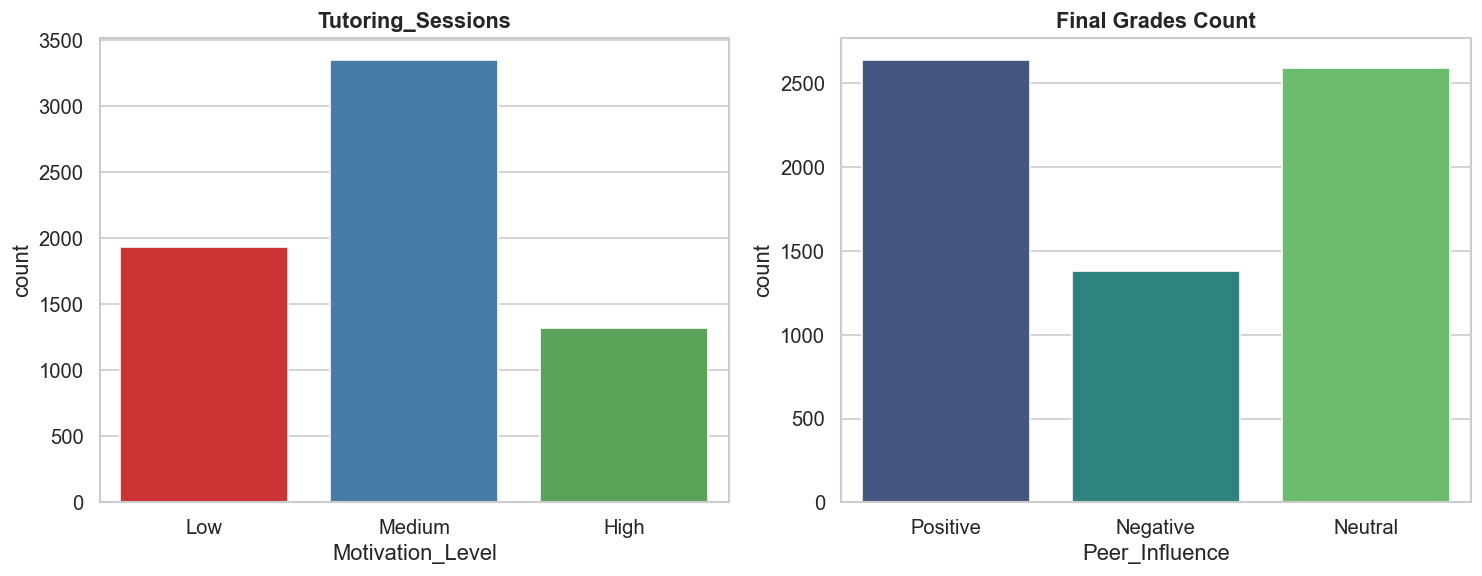

In [20]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Motivation_Level',hue='Motivation_Level', palette='Set1')
plt.title('Tutoring_Sessions')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='Peer_Influence',hue='Peer_Influence',palette='viridis')
plt.title('Final Grades Count')

plt.tight_layout()
plt.show()

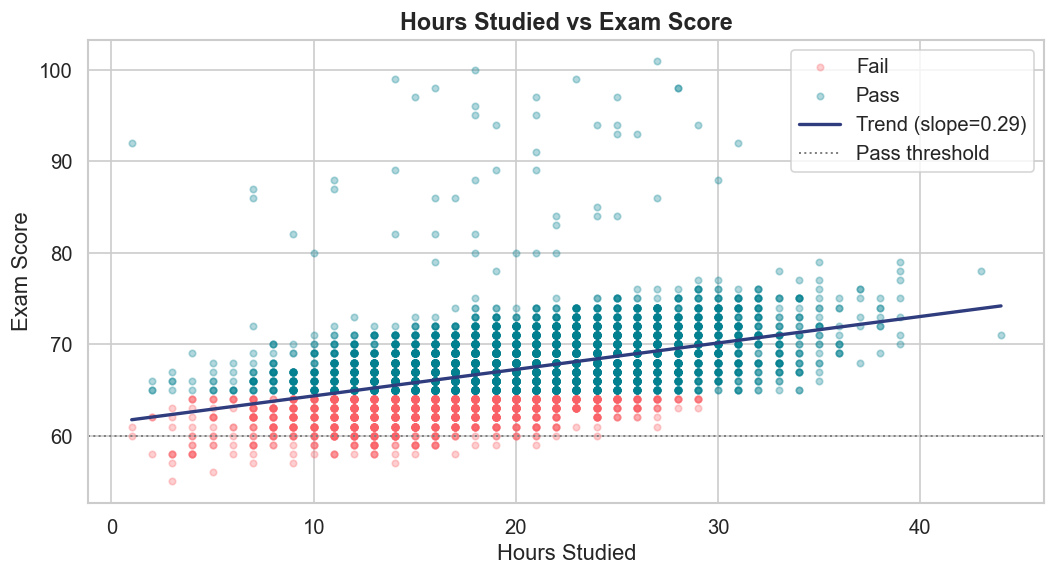

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, grp in df.groupby('Pass_Fail_Label'):
    ax.scatter(grp['Hours_Studied'], grp['Exam_Score'],
               label=label, alpha=0.3, s=15, color=PASS_PALETTE[label])

m, b   = np.polyfit(df['Hours_Studied'], df['Exam_Score'], 1)
x_line = np.linspace(df['Hours_Studied'].min(), df['Hours_Studied'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#2F3C7E', linewidth=2, label=f'Trend (slope={m:.2f})')
ax.axhline(60, color='grey', linestyle=':', linewidth=1.2, label='Pass threshold')

ax.set_title('Hours Studied vs Exam Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
ax.legend()
plt.tight_layout()

plt.show()

C:\Users\Fatma\AppData\Local\Temp\ipykernel_27860\1450807339.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attendance_Group', y='Exam_Score', palette=PALETTE, ax=axes[1])
C:\Users\Fatma\AppData\Local\Temp\ipykernel_27860\1450807339.py:14: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.boxplot(data=df, x='Attendance_Group', y='Exam_Score', palette=PALETTE, ax=axes[1])


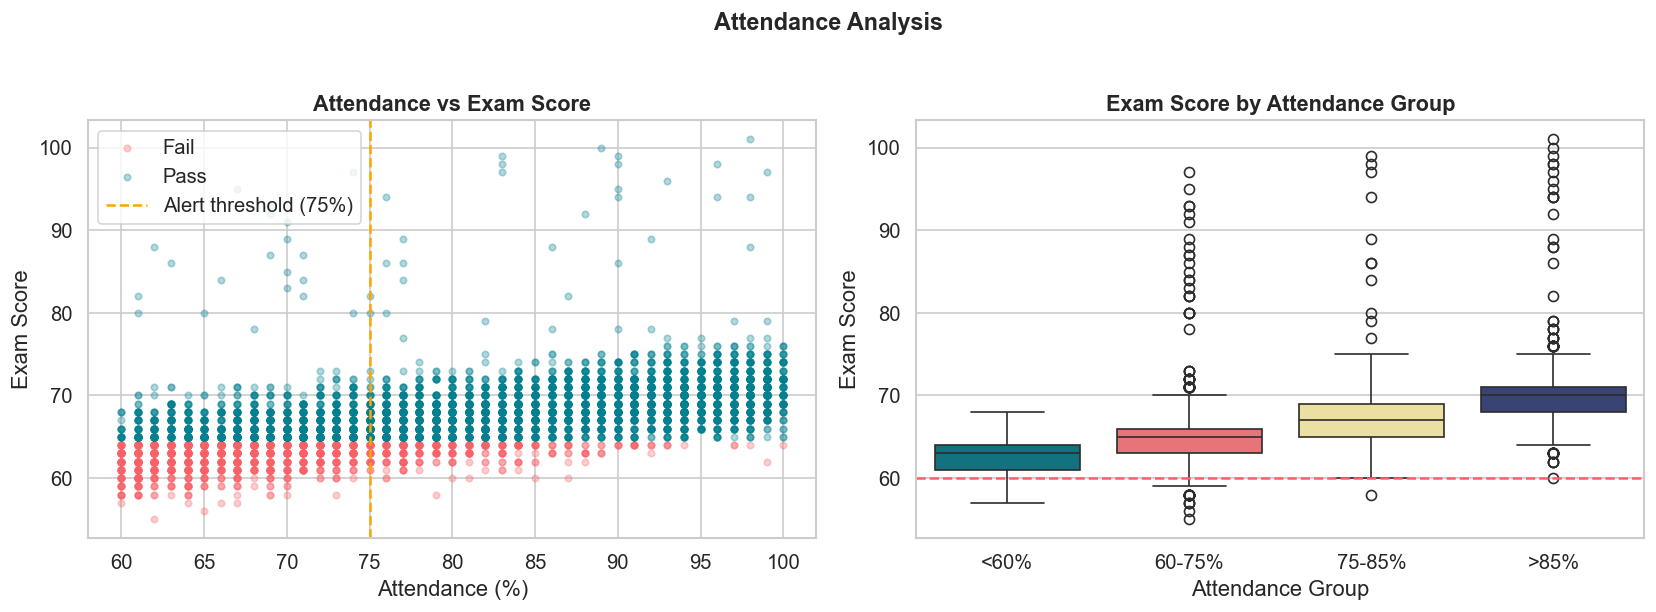

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, grp in df.groupby('Pass_Fail_Label'):
    axes[0].scatter(grp['Attendance'], grp['Exam_Score'],
                    label=label, alpha=0.3, s=15, color=PASS_PALETTE[label])
axes[0].axvline(75, color='orange', linestyle='--', linewidth=1.5, label='Alert threshold (75%)')
axes[0].set_title('Attendance vs Exam Score')
axes[0].set_xlabel('Attendance (%)')
axes[0].set_ylabel('Exam Score')
axes[0].legend()

df['Attendance_Group'] = pd.cut(df['Attendance'], bins=[0, 60, 75, 85, 100],
                                labels=['<60%', '60-75%', '75-85%', '>85%'])
sns.boxplot(data=df, x='Attendance_Group', y='Exam_Score', palette=PALETTE, ax=axes[1])
axes[1].axhline(60, color=PALETTE[1], linestyle='--', linewidth=1.5)
axes[1].set_title('Exam Score by Attendance Group')
axes[1].set_xlabel('Attendance Group')
axes[1].set_ylabel('Exam Score')

plt.suptitle('Attendance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

C:\Users\Fatma\AppData\Local\Temp\ipykernel_27860\3014978140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep_Hours', y='Exam_Score', palette=PALETTE, ax=axes[0])
C:\Users\Fatma\AppData\Local\Temp\ipykernel_27860\3014978140.py:3: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='Sleep_Hours', y='Exam_Score', palette=PALETTE, ax=axes[0])
C:\Users\Fatma\AppData\Local\Temp\ipykernel_27860\3014978140.py:8: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.violinplot(data=df, x='Motivation_Level', y='Exam_Score',


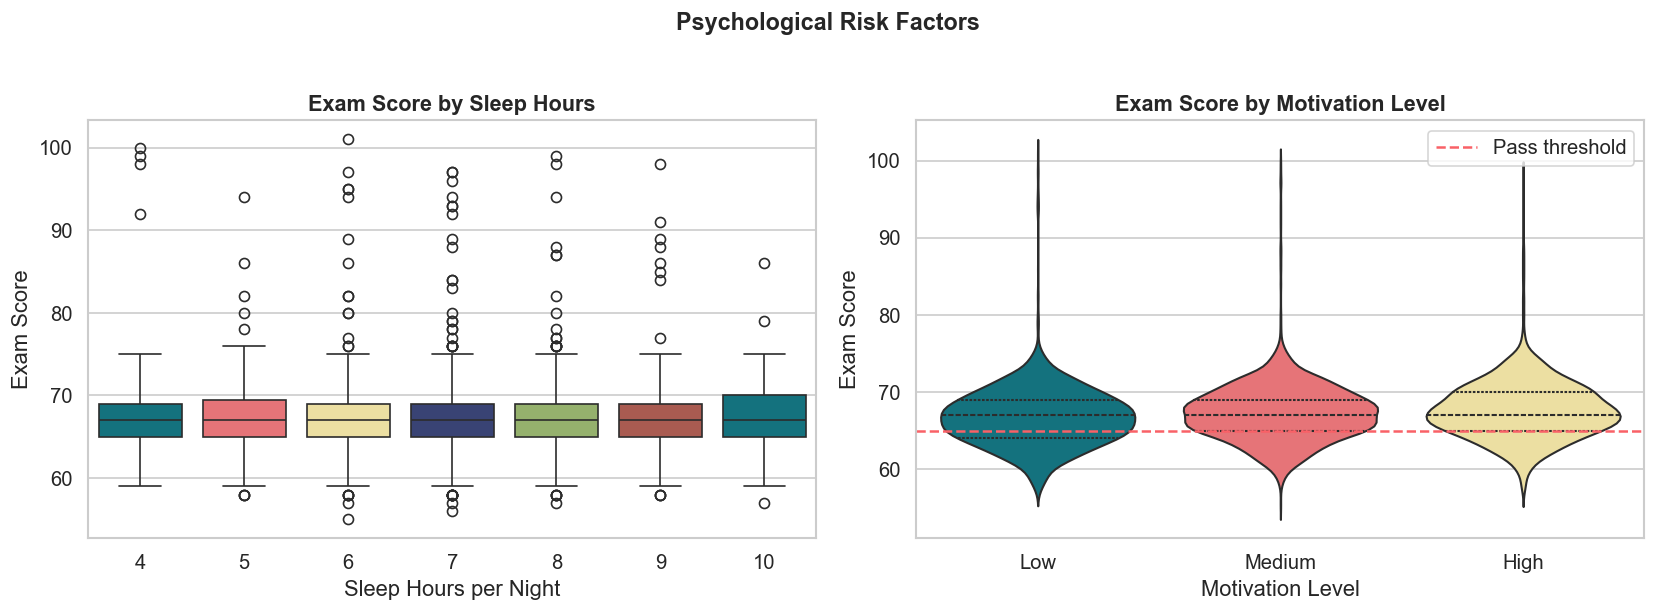

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Sleep_Hours', y='Exam_Score', palette=PALETTE, ax=axes[0])
axes[0].set_title('Exam Score by Sleep Hours')
axes[0].set_xlabel('Sleep Hours per Night')
axes[0].set_ylabel('Exam Score')

sns.violinplot(data=df, x='Motivation_Level', y='Exam_Score',
               order=['Low', 'Medium', 'High'],
               hue='Motivation_Level', palette=PALETTE, legend=False,
               inner='quartile', ax=axes[1])
axes[1].axhline(65, color=PALETTE[1], linestyle='--', linewidth=1.5, label='Pass threshold')
axes[1].set_title('Exam Score by Motivation Level')
axes[1].set_xlabel('Motivation Level')
axes[1].set_ylabel('Exam Score')
axes[1].legend()

plt.suptitle('Psychological Risk Factors', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_07_psychological_factors.png', bbox_inches='tight')
plt.show()

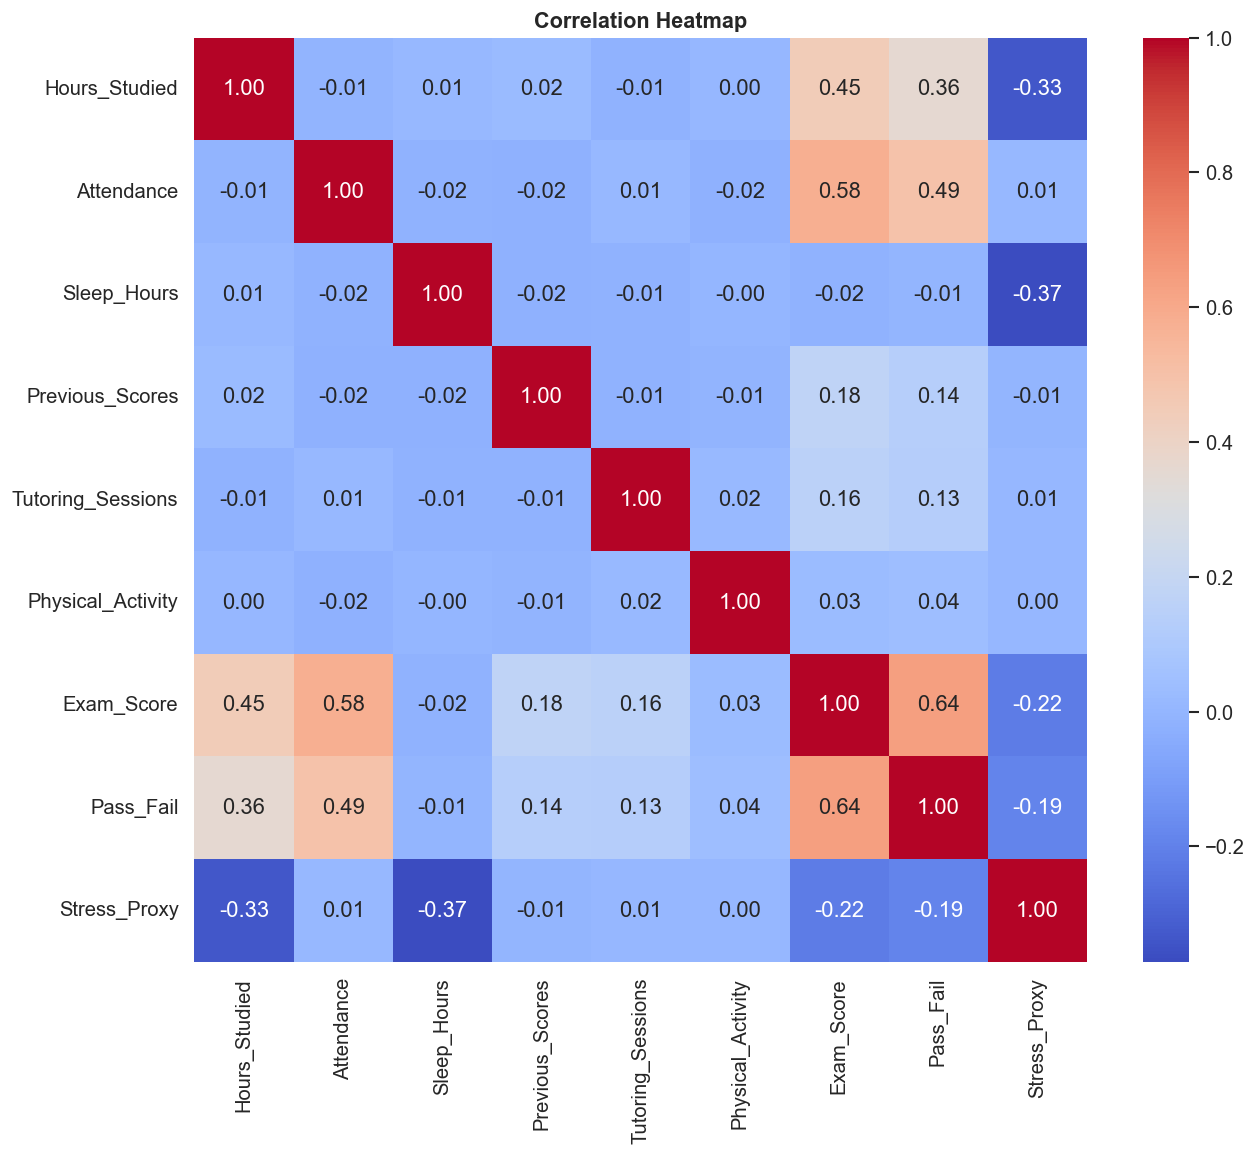

In [24]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

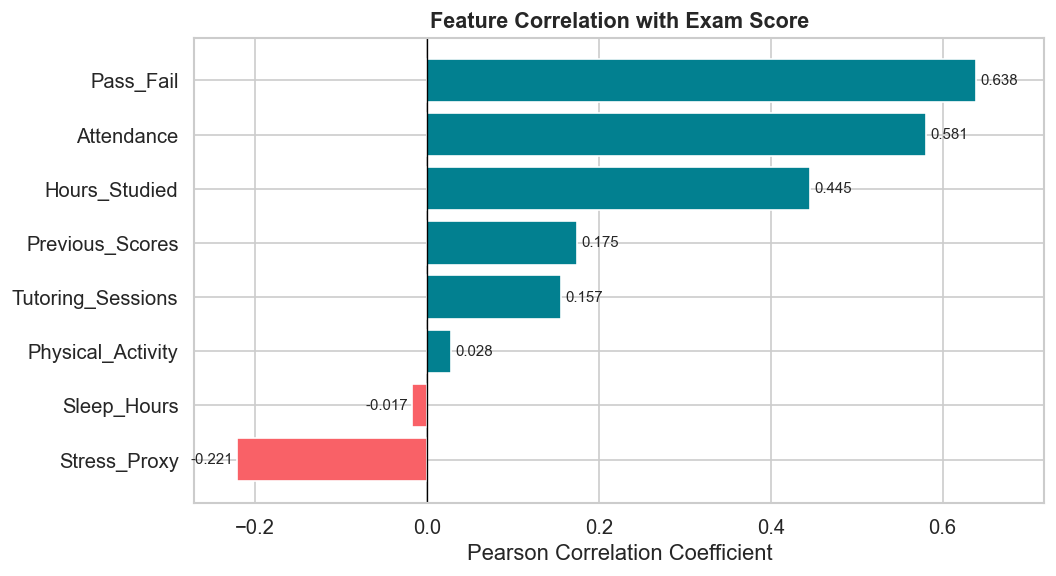

In [25]:
corr_with_target = numeric_df.corr()['Exam_Score'].drop('Exam_Score')
corr_sorted      = corr_with_target.sort_values()
colors           = [PALETTE[1] if v < 0 else PALETTE[0] for v in corr_sorted.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_title('Feature Correlation with Exam Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_xlim(corr_sorted.min() - 0.05, corr_sorted.max() + 0.08)
plt.tight_layout()
plt.savefig('chart_12_feature_correlation.png', bbox_inches='tight')
plt.show()

In [26]:
#Categorical Encoding 


cols_ordinal = ['Motivation_Level', 'Peer_Influence', 'Access_to_Resources', 'Parental_Involvement']
ordinal_order = [
    ['Low', 'Medium', 'High'],          # Motivation_Level
    ['Negative', 'Neutral', 'Positive'], # Peer_Influence
    ['Low', 'Medium', 'High'],          # Access_to_Resources
    ['Low', 'Medium', 'High']
]
cols_onehot = ['Gender', 'Extracurricular_Activities', 'Learning_Disabilities']

#split the target
X = df.drop(columns=['Exam_Score', 'Pass_Fail', 'Pass_Fail_Label', 'Attendance_Group'])
y = df['Pass_Fail']

# (Train-Test Split) to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(categories=ordinal_order, 
                               handle_unknown='use_encoded_value', 
                               unknown_value=-1), cols_ordinal),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, 
                             handle_unknown='ignore'), cols_onehot),
], remainder='passthrough')

# Fit on train & transform on test
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


onehot_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(cols_onehot).tolist()
remainder_cols = [c for c in X_train.columns if c not in cols_ordinal + cols_onehot]
all_cols = cols_ordinal + onehot_names + remainder_cols

X_train_df = pd.DataFrame(X_train_encoded, columns=all_cols)
X_test_df = pd.DataFrame(X_test_encoded, columns=all_cols)


In [27]:
#Class Balance Check
X_train_resampled_input = X_train_df.apply(pd.to_numeric, errors='coerce')

X_train_resampled_input = X_train_resampled_input.fillna(0) 

# 3. التأكد إن مفيش NaN دلوقتي (للأمان)
if X_train_resampled_input.isna().sum().sum() == 0:
    print("Clean Data: No NaNs found. Proceeding to SMOTE...")
    
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train_resampled_input, y_train)
    print('Success! Classes are now balanced.')
else:
    print("Still found NaNs! Please check your encoding step.")

print(f"Shape after SMOTE: {X_train_res.shape}")

Clean Data: No NaNs found. Proceeding to SMOTE...
Success! Classes are now balanced.
Shape after SMOTE: (8248, 14)


In [28]:
import joblib

# حفظ المحول لاستخدامه في Streamlit
joblib.dump(preprocessor, 'data_preprocessor.pkl')

['data_preprocessor.pkl']

In [33]:
# دمج X و y للتدريب وحفظهم
train_final = X_train_res.copy()
train_final['Target'] = y_train_res.values
train_final.to_csv('train_processed.csv', index=False)

# دمج X و y للاختبار وحفظهم
test_final = X_test_df.copy()
test_final['Target'] = y_test.values
test_final.to_csv('test_processed.csv', index=False)

In [30]:
X_train_res.head()

,Motivation_Level,Peer_Influence,Access_to_Resources,Parental_Involvement,Gender_Male,Extracurricular_Activities_Yes,Learning_Disabilities_Yes,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Stress_Proxy
0,0.0,1.0,2.0,1.0,1.0,1.0,0.0,14.0,89.0,6.0,94.0,0.0,2.0,0.6939
1,0.0,2.0,0.0,1.0,0.0,1.0,0.0,22.0,81.0,7.0,80.0,1.0,3.0,0.6000
2,0.0,2.0,2.0,1.0,1.0,0.0,0.0,28.0,94.0,7.0,60.0,1.0,3.0,0.5545
3,2.0,0.0,2.0,1.0,0.0,0.0,0.0,11.0,67.0,8.0,52.0,3.0,3.0,0.3167
4,1.0,0.0,1.0,2.0,1.0,1.0,0.0,22.0,71.0,8.0,63.0,2.0,2.0,0.4000


In [31]:
df.dtypes

Hours_Studied                    int64
Attendance                       int64
Parental_Involvement            object
Access_to_Resources             object
Extracurricular_Activities      object
Sleep_Hours                      int64
Previous_Scores                  int64
Motivation_Level                object
Tutoring_Sessions                int64
Peer_Influence                  object
Physical_Activity                int64
Learning_Disabilities           object
Gender                          object
Exam_Score                       int64
Pass_Fail                        int32
Pass_Fail_Label                 object
Stress_Proxy                   float64
Attendance_Group              category
dtype: object

KeyError: 0

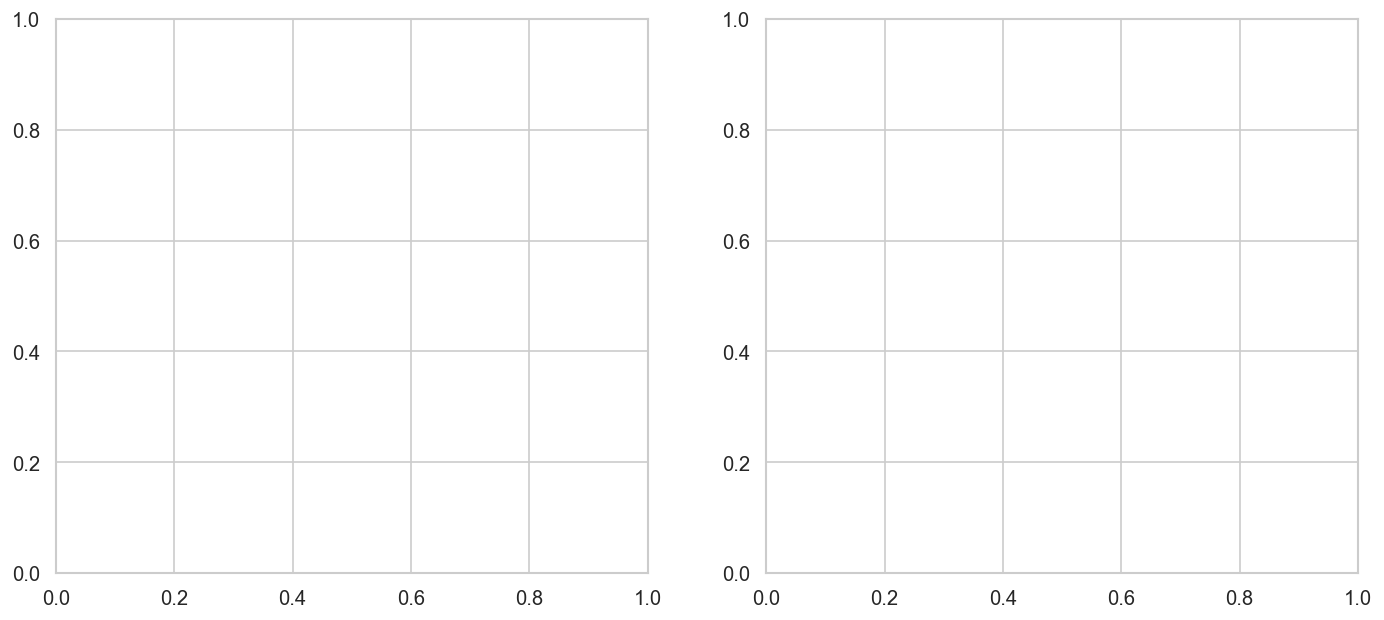

In [32]:
counts_before = y_train.value_counts(normalize=True)
counts_after  = pd.Series(y_train_res).value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = [0, 1]
values_before = [counts_before.get(0, 0) * 100, counts_before.get(1, 0) * 100]
colors = [PASS_PALETTE[0], PASS_PALETTE[1]]

bars1 = axes[0].bar([LABEL_MAP[c] for c in categories], values_before, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Original)')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_ylim(0, 100)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.1f}%', ha='center', fontweight='bold', color='#2F3C7E')

# After SMOTE
values_after = [counts_after.get(0, 0) * 100, counts_after.get(1, 0) * 100]

bars2 = axes[1].bar([LABEL_MAP[c] for c in categories], values_after, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Class Distribution (After SMOTE)')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 100)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.1f}%', ha='center', fontweight='bold', color='#2F3C7E')

plt.suptitle('Effect of SMOTE on Class Balance', fontsize=16, fontweight='bold', y=1.05, color='#2F3C7E')
plt.tight_layout()

plt.show()